## Load Data
Pada eksperimen share vs non-share parameter, kami menjalankan notebook ini di Collab agar bisa memanfaatkan GPU yang ada. Dataset di-download dan di ekstrak di lokal. Karena keterbatasan push data besar ke github, maka dataset tidak di push ke repository dan dapat diakses melalui kaggle https://www.kaggle.com/datasets/puneet6060/intel-image-classification. 

In [6]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import f1_score
from PIL import Image
import os
import glob
import gdown
import zipfile

from layers import CNN, Conv2D, LocallyConnected2D, MaxAvgPooling2D, Flatten, Dense, FungsiAktivasi

In [1]:
!pip install gdown


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
url = "https://drive.google.com/file/d/19csBcImwszU2Ly0acoDPNB9Kj0_HOAFM/view?usp=drive_link"

base_dir = "../../data/cnn_data"
zip_path = os.path.join(base_dir, "dataset.zip")

test_dir = os.path.join(base_dir, "seg_test")

os.makedirs(base_dir, exist_ok=True)

if not os.path.exists(zip_path):
    print("Dataset zip belum ada, downloading.")
    
    gdown.download(url, zip_path, quiet=False)
else:
    print("Dataset zip sudah ada, skip download.")

if not (os.path.exists(test_dir)):
    print("Folder dataset belum ada, extracting zip.")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(base_dir)
else:
    print("Folder dataset sudah ada, skip extract.")

test_dir = "../../data/cnn_data/seg_test/seg_test"

IMG_SIZE = (150, 150)
BATCH_SIZE = 32


print("\nLoad Data Testing:")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False 
)

y_true = np.concatenate([y for x, y in test_ds], axis=0)
print(f"\nJumlah label test: {y_true.shape[0]}")

Dataset zip sudah ada, skip download.
Folder dataset sudah ada, skip extract.

Load Data Testing:
Found 3000 files belonging to 6 classes.

Jumlah label test: 3000


## Load Bobot Hasil Training

In [8]:
def get_keras_weights_3_layer(file_path):
    # Kombinasi 12 :  3 Layer, Filter 32->64->128, Kernel 5x5, Avg Pooling
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(150, 150, 3)),
        
        # Layer 1
        tf.keras.layers.Conv2D(32, (5,5), activation='relu', padding='same', name='conv1'),
        tf.keras.layers.AveragePooling2D((2,2)),
        
        # Layer 2
        tf.keras.layers.Conv2D(64, (5,5), activation='relu', padding='same', name='conv2'),
        tf.keras.layers.AveragePooling2D((2,2)),
        
        # Layer 3
        tf.keras.layers.Conv2D(128, (5,5), activation='relu', padding='same', name='conv3'),
        tf.keras.layers.AveragePooling2D((2,2)),
        
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu', name='dense1'),
        tf.keras.layers.Dense(6, activation='softmax', name='dense2')
    ])
    
    model.load_weights(file_path)
    
    w_c1, b_c1 = model.get_layer('conv1').get_weights()
    w_c2, b_c2 = model.get_layer('conv2').get_weights()
    w_c3, b_c3 = model.get_layer('conv3').get_weights()
    
    w_d1, b_d1 = model.get_layer('dense1').get_weights()
    w_d2, b_d2 = model.get_layer('dense2').get_weights()
    
    return (w_c1, b_c1), (w_c2, b_c2), (w_c3, b_c3), (w_d1, b_d1), (w_d2, b_d2)

weights_3L = get_keras_weights_3_layer("../weights/Kombinasi_12.weights.h5")
(c1_w, c1_b), (c2_w, c2_b), (c3_w, c3_b), (d1_w, d1_b), (d2_w, d2_b) = weights_3L

c:\Users\diyah\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [9]:
print("Bobot dan bias layer 1 (Conv2D):")
print("Bobot:", c1_w) 
print("Bias:", c1_b)
print("\nBobot dan bias layer 2 (Conv2D):")
print("Bobot:", c2_w)
print("Bias:", c2_b)
print("\nBobot dan bias layer 3 (Conv2D):")
print("Bobot:", c3_w)
print("Bias:", c3_b)
print("\nBobot dan bias layer 4 (Dense):")
print("Bobot:", d1_w)
print("Bias:", d1_b)
print("\nBobot dan bias layer 5 (Dense):")
print("Bobot:", d2_w)
print("Bias:", d2_b)

Bobot dan bias layer 1 (Conv2D):
Bobot: [[[[ 0.06702299  0.00712245  0.07723694 ... -0.01036673  0.00427986
    -0.00419013]
   [ 0.09371116  0.08415554  0.05826316 ...  0.01258234  0.01807517
     0.00704858]
   [ 0.03652676  0.10825375 -0.04147444 ... -0.07240404  0.09318809
     0.06616022]]

  [[ 0.05176375  0.02977443 -0.05200756 ...  0.07748219 -0.0189621
    -0.00482459]
   [-0.00817803 -0.0163733   0.10343851 ...  0.02757369  0.0600509
    -0.10395478]
   [ 0.05437732 -0.04121814  0.04402867 ...  0.0371697   0.0768166
    -0.11210621]]

  [[-0.0191365  -0.10324041 -0.0161722  ... -0.03780828 -0.06237955
    -0.05829372]
   [-0.04359397 -0.14501534 -0.03746882 ...  0.02078372 -0.08621041
     0.0454138 ]
   [ 0.05613543 -0.04717083 -0.03710762 ... -0.01361197  0.0087716
     0.05258601]]

  [[ 0.03777636 -0.00952904 -0.16595429 ...  0.0262029   0.0319996
     0.02150762]
   [ 0.09043638  0.00248785 -0.13152263 ... -0.01408211  0.03588619
    -0.01801616]
   [ 0.05020424 -0.12276

## Model From Scratch

In [10]:
# model from scratch
cnn_model_3_layer = CNN(layers=[
    # later 1 (Filter: 32)
    Conv2D(kernel_weights=c1_w, bias_weights=c1_b, stride=1, padding=2), 
    FungsiAktivasi(tipe='relu'),
    MaxAvgPooling2D(pool_size=(2, 2), stride=2, tipe='avg'), # Output ukuran: 75x75x32

    # layer 2 (Filter: 64)
    Conv2D(kernel_weights=c2_w, bias_weights=c2_b, stride=1, padding=2), 
    FungsiAktivasi(tipe='relu'),
    MaxAvgPooling2D(pool_size=(2, 2), stride=2, tipe='avg'), # Output ukuran: 37x37x64

    # layer 3 (Filter: 128)
    Conv2D(kernel_weights=c3_w, bias_weights=c3_b, stride=1, padding=2), 
    FungsiAktivasi(tipe='relu'),
    MaxAvgPooling2D(pool_size=(2, 2), stride=2, tipe='avg'), # Output ukuran: 18x18x128

    Flatten(),
    
    Dense(weights=d1_w, bias=d1_b), 
    FungsiAktivasi(tipe='relu'),
    
    Dense(weights=d2_w, bias=d2_b) 
])


## Model Keras

In [12]:
model_keras_shared = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(150, 150, 3)),
        
        # Layer 1
        tf.keras.layers.Conv2D(32, (5,5), activation='relu', padding='same', name='conv1'),
        tf.keras.layers.AveragePooling2D((2,2)),
        
        # Layer 2
        tf.keras.layers.Conv2D(64, (5,5), activation='relu', padding='same', name='conv2'),
        tf.keras.layers.AveragePooling2D((2,2)),
        
        # Layer 3
        tf.keras.layers.Conv2D(128, (5,5), activation='relu', padding='same', name='conv3'),
        tf.keras.layers.AveragePooling2D((2,2)),
        
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu', name='dense1'),
        tf.keras.layers.Dense(6, activation='softmax', name='dense2')
    ])

model_keras_shared.load_weights("../weights/Kombinasi_12.weights.h5")

c:\Users\diyah\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


## Prediksi dan Evaluasi

In [17]:
from PIL import Image

def siapkan_gambar(image_path):
    img = Image.open(image_path).convert('RGB').resize((150, 150))
    img_array = np.array(img)
    img_array = img_array / 255.0 
    return img_array.astype(np.float32)

In [16]:
def predict_from_scratch(model, image_path):
    input_tensor = siapkan_gambar(image_path)
    
    output = input_tensor
    for layer in model.layers:
        output = layer.forward(output)

    pred_index = np.argmax(output)
    daftar_kelas = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
    label_prediksi = daftar_kelas[pred_index]
    
    return label_prediksi, output

MEMULAI EVALUASI PERBANDINGAN: SCRATCH VS KERAS

Memproses kelas: BUILDINGS

Memproses kelas: FOREST

Memproses kelas: GLACIER

Memproses kelas: MOUNTAIN

Memproses kelas: SEA

Memproses kelas: STREET

HASIL AKHIR MACRO F1-SCORE:
  > FROM SCRATCH : 0.8071
  > FROM KERAS   : 0.8071


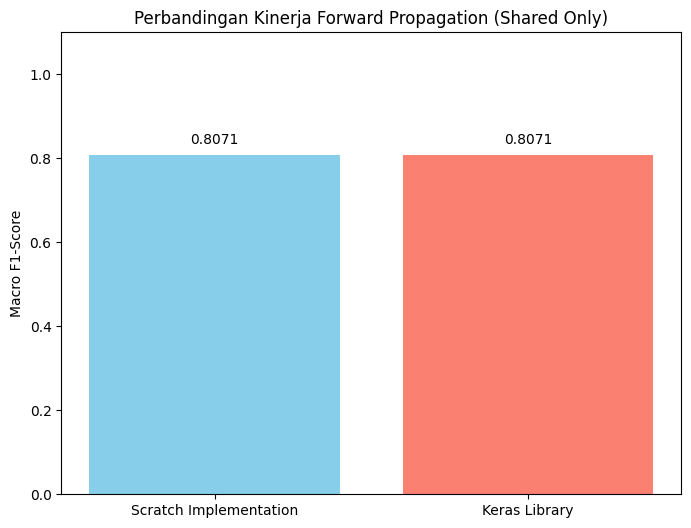

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import tensorflow as tf

folder_test = r"../../data/cnn_data/seg_test/seg_test"

daftar_kelas = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

y_true = []
y_pred_scratch = []
y_pred_keras = []

print("="*60)
print("MEMULAI EVALUASI PERBANDINGAN: SCRATCH VS KERAS")
print("="*60)

for kelas in daftar_kelas:
    path_folder_kelas = os.path.join(folder_test, kelas)
    list_gambar = glob.glob(os.path.join(path_folder_kelas, "*.jpg"))
    
    print(f"\nMemproses kelas: {kelas.upper()}")
    
    gambar_yg_diproses = list_gambar
    
    for path_gambar in gambar_yg_diproses:
        y_true.append(kelas)
        
        label_scratch, _ = predict_from_scratch(cnn_model_3_layer, path_gambar)
        y_pred_scratch.append(label_scratch)
        
        img = tf.keras.utils.load_img(path_gambar, target_size=(150, 150))
        img_array = tf.keras.utils.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0) 
        
        pred_keras_raw = model_keras_shared.predict(img_array, verbose=0)
        label_keras = daftar_kelas[np.argmax(pred_keras_raw)]
        y_pred_keras.append(label_keras)

f1_scratch = f1_score(y_true, y_pred_scratch, average='macro', zero_division=0)
f1_keras = f1_score(y_true, y_pred_keras, average='macro', zero_division=0)

print("\n" + "="*60)
print(f"HASIL AKHIR MACRO F1-SCORE:")
print(f"  > FROM SCRATCH : {f1_scratch:.4f}")
print(f"  > FROM KERAS   : {f1_keras:.4f}")
print("="*60)

labels = ['Scratch Implementation', 'Keras Library']
scores = [f1_scratch, f1_keras]

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, scores, color=['skyblue', 'salmon'])
plt.ylim(0, 1.1)
plt.ylabel('Macro F1-Score')
plt.title('Perbandingan Kinerja Forward Propagation (Shared Only)')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 4), ha='center', va='bottom')

plt.show()

In [18]:
import os
import glob
import pandas as pd

list_path = []

for kelas in daftar_kelas:
    path_folder_kelas = os.path.join(folder_test, kelas)
    list_gambar = glob.glob(os.path.join(path_folder_kelas, "*.jpg"))

    for path_gambar in list_gambar:
        relative_path = os.path.join(kelas, os.path.basename(path_gambar))
        list_path.append(relative_path)

print(len(list_path))
print(len(y_true))
print(len(y_pred_scratch))
print(len(y_pred_keras))

3000
3000
3000
3000


In [19]:
hasil_prediksi = pd.DataFrame({
    'path_gambar': list_path,
    'label_asli': y_true,
    'pred_scratch': y_pred_scratch,
    'pred_keras': y_pred_keras
})

hasil_prediksi.to_csv("hasil_prediksi.csv", index=False)

print("CSV berhasil disimpan!")

CSV berhasil disimpan!


## Analisis
Berdasarkan hasil performa F1-Score untuk forward propagation cnn, diperoleh nilai sebesar 0.8071. Nilai ini sudah sama persis dengan prediksi menggunakan model Keras. Hal ini menandakan bahwa implementasi CNN from scratch telah berhasil diimplementasikan dengan benar. Model CNN from scratch yang dikembangkan telah tervalidasi sepenuhnya dan berfungsi dengan benar sebagai representasi white-box dari library Keras.